In [2]:
!pip install tensorflow opencv-python

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical

2025-08-07 15:21:06.523951: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754580066.888519      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754580066.993190      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Baseline model on human CENPARMI data 5-folds cross validation without any Augmentation

/tmp/ipykernel_36/1935648085.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('label').apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)
I0000 00:00:1754024805.887082      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1754024805.887798      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 14,747,715 (56.26 MB)

...

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 204ms/step - accuracy: 0.3093 - loss: 11.3590 - val_accuracy: 0.3509 - val_loss: 5.5331
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.3443 - loss: 10.4096 - val_accuracy: 0.3991 - val_loss: 3.6163
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.4226 - loss: 7.7828 - val_accuracy: 0.4781 - val_loss: 2.6665
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - accuracy: 0.3877 - loss: 7.7192 - val_accuracy: 0.5526 - val_loss: 2.0233
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.4005 - loss: 7.2103 - val_accuracy: 0.6447 - val_loss: 1.6556
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - accuracy: 0.4390 - loss: 5.8677 - val_accuracy: 0.6842 - val_loss: 1.4901
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.5286 - loss: 5.5356 - val_accuracy: 0.7149 - val_loss: 1.3491
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - accuracy: 0.5236 - loss: 5.1333 - val_accuracy: 

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 207ms/step - accuracy: 0.3354 - loss: 12.7968 - val_accuracy: 0.5219 - val_loss: 4.6102
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - accuracy: 0.4223 - loss: 9.8626 - val_accuracy: 0.5702 - val_loss: 2.9411
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - accuracy: 0.4634 - loss: 8.4281 - val_accuracy: 0.6623 - val_loss: 2.2658
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - accuracy: 0.4258 - loss: 7.8053 - val_accuracy: 0.7105 - val_loss: 1.9457
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.4699 - loss: 6.9964 - val_accuracy: 0.7456 - val_loss: 1.7007
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - accuracy: 0.5040 - loss: 6.3103 - val_accuracy: 0.7807 - val_loss: 1.5420
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.5094 - loss: 6.1223 - val_accuracy: 0.8026 - val_loss: 1.4542
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - accuracy: 0.5419 - loss: 5.0229 - val_accuracy: 0

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 207ms/step - accuracy: 0.3157 - loss: 12.9857 - val_accuracy: 0.3596 - val_loss: 4.1316
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.3325 - loss: 9.9080 - val_accuracy: 0.4781 - val_loss: 2.6631
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.3776 - loss: 8.3907 - val_accuracy: 0.5746 - val_loss: 2.1021
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.4045 - loss: 7.3545 - val_accuracy: 0.6535 - val_loss: 1.8355
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.4545 - loss: 6.0394 - val_accuracy: 0.6754 - val_loss: 1.6929
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.4311 - loss: 6.0866 - val_accuracy: 0.7281 - val_loss: 1.5850
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - accuracy: 0.4927 - loss: 5.6207 - val_accuracy: 0.7675 - val_loss: 1.4964
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - accuracy: 0.5060 - loss: 4.8021 - val_accuracy: 0

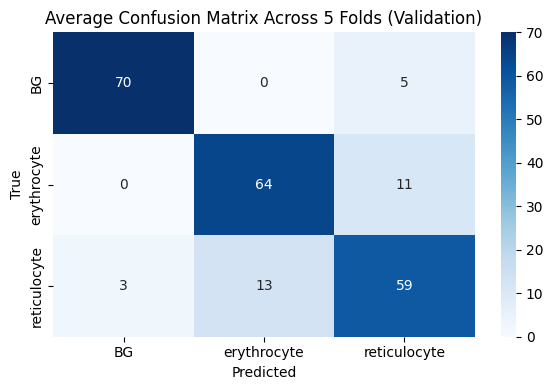

,Metric,Mean,Std Dev
0,Val Accuracy,8.526316e-01,0.023308
1,Val Precision,8.544056e-01,0.022327
2,Val Recall,8.526316e-01,0.023308
3,Val F1 Score,8.529274e-01,0.022707
4,Test Accuracy,8.575439e-01,0.031273
5,Test Precision,8.630923e-01,0.029468
6,Test Recall,8.575439e-01,0.031273
7,Test F1 Score,8.584541e-01,0.031320
8,Training Time (s),8.289235e+01,3.808501
9,Model Size (MB),5.660435e+01,0.000012


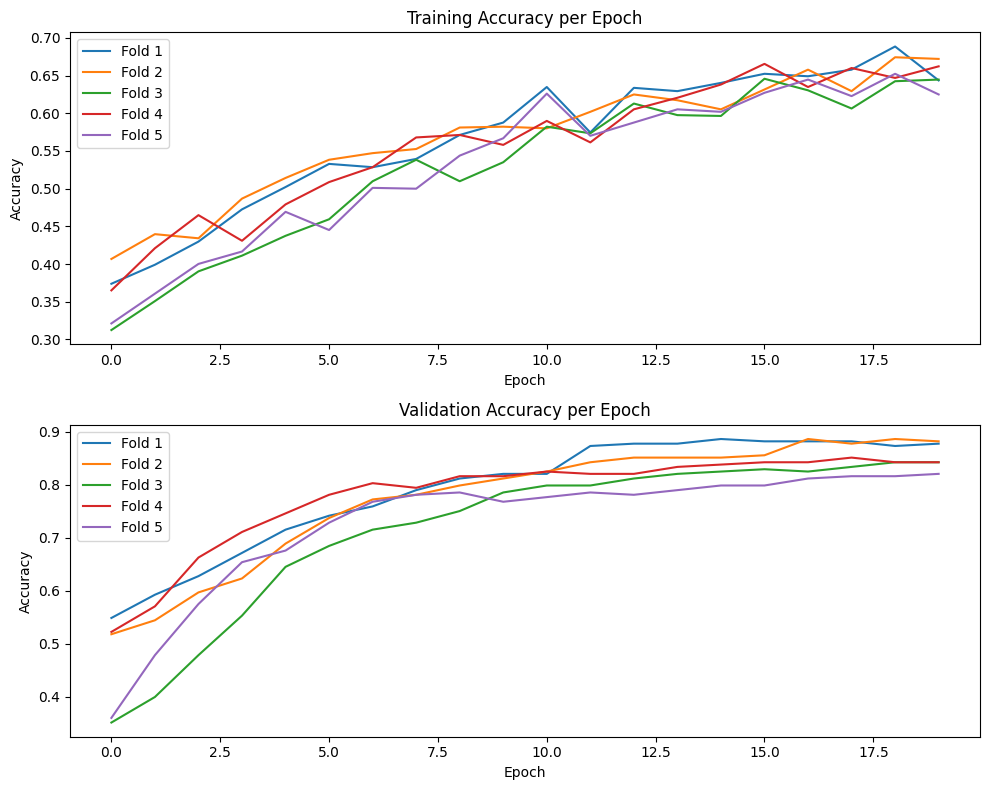

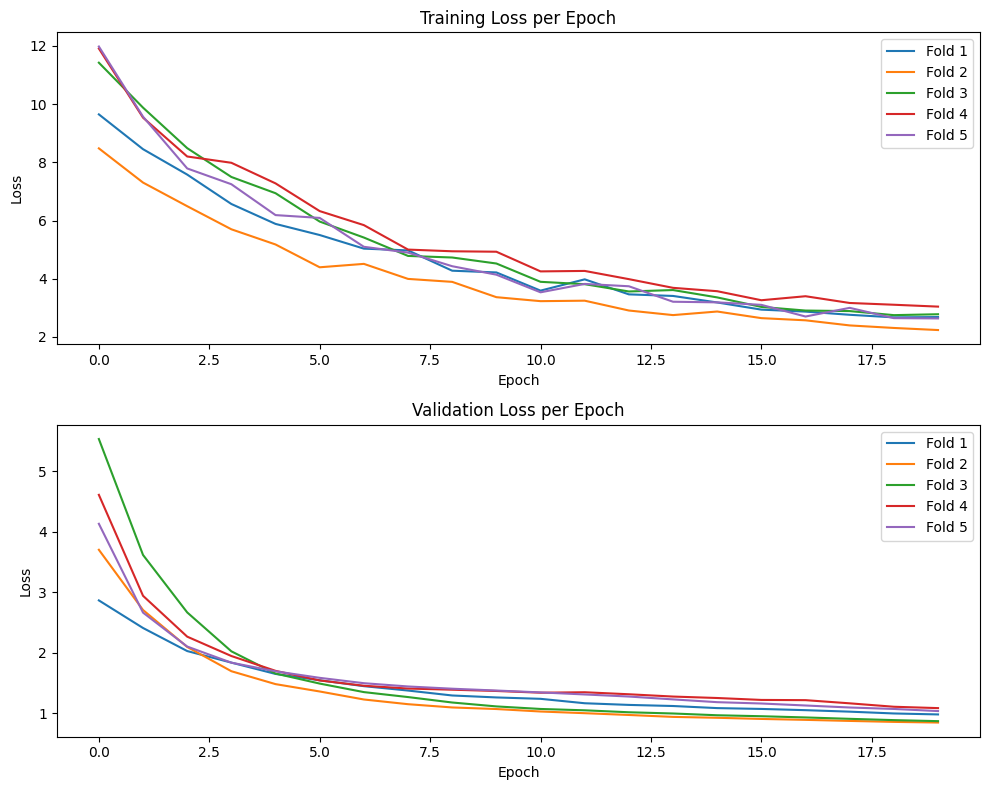

In [2]:
import os, time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import CategoricalCrossentropy

# Config
DATA_DIR = '/kaggle/input/human-reticulocyte/SubsetAlldata'
IMG_SIZE = (64, 64)
BATCH_SIZE = 32
FOLDS = 5
EPOCHS = 20

# Load and balance dataset
all_data = [(os.path.join(DATA_DIR, label, fname), label)
            for label in os.listdir(DATA_DIR)
            for fname in os.listdir(os.path.join(DATA_DIR, label))]
df = pd.DataFrame(all_data, columns=['filepath', 'label'])

min_count = df['label'].value_counts().min()
df = df.groupby('label').apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)
df['encoded'] = LabelEncoder().fit_transform(df['label'])

class_names = df['label'].unique()
num_classes = len(class_names)

# Split 80% TrainVal and 20% Test
train_val_df, test_df = train_test_split(df, test_size=0.2, stratify=df['encoded'], random_state=42)

# Preview model once
temp_base = VGG16(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
for layer in temp_base.layers:
    layer.trainable = False
x = GlobalAveragePooling2D()(temp_base.output)
x = Dropout(0.4)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)
temp_model = Model(inputs=temp_base.input, outputs=output)
temp_model.summary()

# Generators
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = datagen.flow_from_dataframe(test_df, x_col='filepath', y_col='label',
                                       target_size=IMG_SIZE, class_mode='categorical',
                                       batch_size=BATCH_SIZE, shuffle=False)

# Cross-validation setup
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)
accs, precs, recs, f1s = [], [], [], []
test_accs, test_precs, test_recs, test_f1s = [], [], [], []
times, sizes, params = [], [], []
all_cm = np.zeros((num_classes, num_classes), dtype=int)
fold_histories = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_val_df['filepath'], train_val_df['encoded'])):
    print(f"\n🌀 Fold {fold+1}/{FOLDS}")
    train_df, val_df = train_val_df.iloc[train_idx], train_val_df.iloc[val_idx]

    train_gen = datagen.flow_from_dataframe(train_df, x_col='filepath', y_col='label',
                                            target_size=IMG_SIZE, class_mode='categorical',
                                            batch_size=BATCH_SIZE, shuffle=True)
    val_gen = datagen.flow_from_dataframe(val_df, x_col='filepath', y_col='label',
                                          target_size=IMG_SIZE, class_mode='categorical',
                                          batch_size=BATCH_SIZE, shuffle=False)

    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    for layer in base_model.layers:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=output)

    model.compile(optimizer=Adam(1e-4),
                  loss=CategoricalCrossentropy(label_smoothing=0.1),
                  metrics=['accuracy'])

    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    start = time.time()
    history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS, callbacks=[es], verbose=1)
    elapsed = time.time() - start
    times.append(elapsed)
    fold_histories.append(history.history)

    # Validation performance
    y_val_true = val_gen.classes
    y_val_pred = np.argmax(model.predict(val_gen), axis=1)
    accs.append(accuracy_score(y_val_true, y_val_pred))
    precs.append(precision_score(y_val_true, y_val_pred, average='macro'))
    recs.append(recall_score(y_val_true, y_val_pred, average='macro'))
    f1s.append(f1_score(y_val_true, y_val_pred, average='macro'))
    all_cm += confusion_matrix(y_val_true, y_val_pred, labels=range(num_classes))

    # Test performance
    y_test_true = test_gen.classes
    y_test_pred = np.argmax(model.predict(test_gen), axis=1)
    test_accs.append(accuracy_score(y_test_true, y_test_pred))
    test_precs.append(precision_score(y_test_true, y_test_pred, average='macro'))
    test_recs.append(recall_score(y_test_true, y_test_pred, average='macro'))
    test_f1s.append(f1_score(y_test_true, y_test_pred, average='macro'))

    # Model stats
    model.save("temp_model.h5")
    sizes.append(os.path.getsize("temp_model.h5") / (1024 * 1024))
    os.remove("temp_model.h5")
    params.append(model.count_params())

# Final Confusion Matrix (Validation Avg)
plt.figure(figsize=(6, 4))
sns.heatmap(all_cm // FOLDS, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Average Confusion Matrix Across 5 Folds (Validation)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Summary Table
summary_df = pd.DataFrame({
    "Metric": ["Val Accuracy", "Val Precision", "Val Recall", "Val F1 Score",
               "Test Accuracy", "Test Precision", "Test Recall", "Test F1 Score",
               "Training Time (s)", "Model Size (MB)", "Parameters"],
    "Mean": [np.mean(accs), np.mean(precs), np.mean(recs), np.mean(f1s),
             np.mean(test_accs), np.mean(test_precs), np.mean(test_recs), np.mean(test_f1s),
             np.mean(times), np.mean(sizes), np.mean(params)],
    "Std Dev": [np.std(accs), np.std(precs), np.std(recs), np.std(f1s),
                np.std(test_accs), np.std(test_precs), np.std(test_recs), np.std(test_f1s),
                np.std(times), np.std(sizes), np.std(params)]
})
display(summary_df)

# Accuracy Plots
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
for i, history in enumerate(fold_histories):
    axs[0].plot(history['accuracy'], label=f'Fold {i+1}')
    axs[1].plot(history['val_accuracy'], label=f'Fold {i+1}')
axs[0].set_title("Training Accuracy per Epoch")
axs[1].set_title("Validation Accuracy per Epoch")
for ax in axs:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
plt.tight_layout()
plt.show()

# Loss Plots
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
for i, history in enumerate(fold_histories):
    axs[0].plot(history['loss'], label=f'Fold {i+1}')
    axs[1].plot(history['val_loss'], label=f'Fold {i+1}')
axs[0].set_title("Training Loss per Epoch")
axs[1].set_title("Validation Loss per Epoch")
for ax in axs:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
plt.tight_layout()
plt.show()


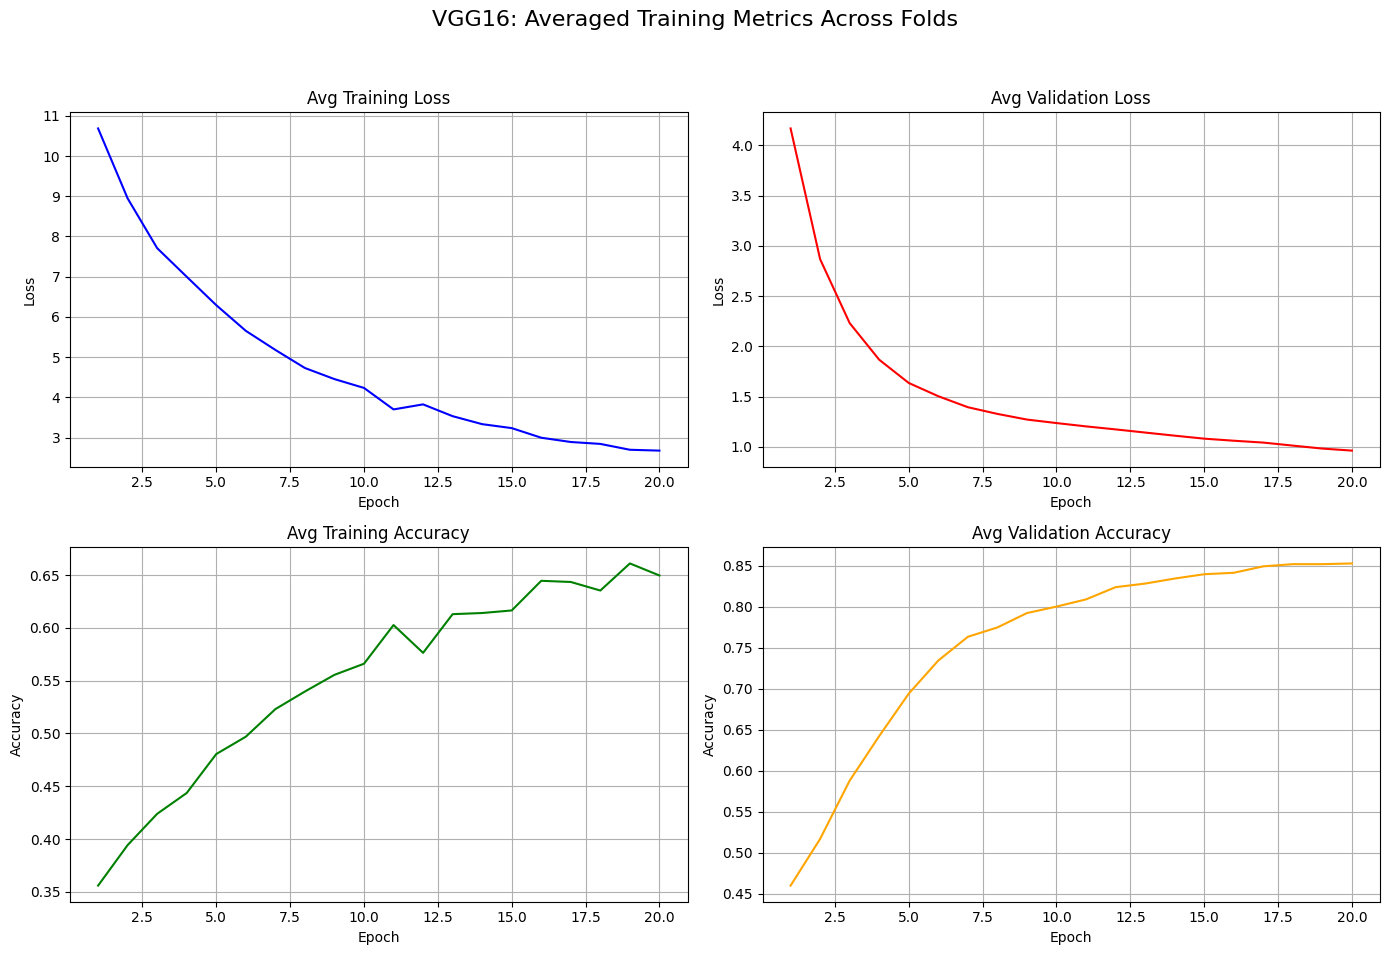

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot_all_avg_metrics(fold_histories, model_name="Model"):
    # Determine max number of epochs across folds
    max_epochs = max(len(h['loss']) for h in fold_histories)

    # Pad histories with NaNs for alignment
    train_loss_all, val_loss_all = [], []
    train_acc_all, val_acc_all = [], []

    for h in fold_histories:
        ep = len(h['loss'])
        train_loss_all.append(np.pad(h['loss'], (0, max_epochs - ep), constant_values=np.nan))
        val_loss_all.append(np.pad(h['val_loss'], (0, max_epochs - ep), constant_values=np.nan))
        train_acc_all.append(np.pad(h['accuracy'], (0, max_epochs - ep), constant_values=np.nan))
        val_acc_all.append(np.pad(h['val_accuracy'], (0, max_epochs - ep), constant_values=np.nan))

    # Convert to arrays
    train_loss_avg = np.nanmean(np.array(train_loss_all), axis=0)
    val_loss_avg = np.nanmean(np.array(val_loss_all), axis=0)
    train_acc_avg = np.nanmean(np.array(train_acc_all), axis=0)
    val_acc_avg = np.nanmean(np.array(val_acc_all), axis=0)

    # Plotting
    epochs_range = range(1, max_epochs + 1)
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))

    axs[0, 0].plot(epochs_range, train_loss_avg, color='blue')
    axs[0, 0].set_title('Avg Training Loss')
    axs[0, 0].set_xlabel('Epoch')
    axs[0, 0].set_ylabel('Loss')
    axs[0, 0].grid()

    axs[0, 1].plot(epochs_range, val_loss_avg, color='red')
    axs[0, 1].set_title('Avg Validation Loss')
    axs[0, 1].set_xlabel('Epoch')
    axs[0, 1].set_ylabel('Loss')
    axs[0, 1].grid()

    axs[1, 0].plot(epochs_range, train_acc_avg, color='green')
    axs[1, 0].set_title('Avg Training Accuracy')
    axs[1, 0].set_xlabel('Epoch')
    axs[1, 0].set_ylabel('Accuracy')
    axs[1, 0].grid()

    axs[1, 1].plot(epochs_range, val_acc_avg, color='orange')
    axs[1, 1].set_title('Avg Validation Accuracy')
    axs[1, 1].set_xlabel('Epoch')
    axs[1, 1].set_ylabel('Accuracy')
    axs[1, 1].grid()

    fig.suptitle(f'{model_name}: Averaged Training Metrics Across Folds', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# 🔁 Call this after training is done
plot_all_avg_metrics(fold_histories, model_name="VGG16")


Found 285 validated image filenames belonging to 3 classes.


/tmp/ipykernel_36/4235533422.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('label').apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)



🌀 Fold 1/5
Found 912 validated image filenames belonging to 3 classes.
Found 228 validated image filenames belonging to 3 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 15s 156ms/step - accuracy: 0.3497 - loss: 5.9192 - val_accuracy: 0.5088 - val_loss: 1.7929 - learning_rate: 1.0000e-04
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.4378 - loss: 4.1557 - val_accuracy: 0.6009 - val_loss: 1.1484 - learning_rate: 1.0000e-04
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.4494 - loss: 4.0629 - val_accuracy: 0.7237 - val_loss: 0.9285 - learning_rate: 1.0000e-04
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.5474 - loss: 3.5576 - val_accuracy: 0.8202 - val_loss: 0.8329 - learning_rate: 1.0000e-04
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.5808 - loss: 2.8395 - val_accuracy: 0.8421 - val_loss: 0.8235 - learning_rate: 1.0000e-04
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.6273 - loss: 2.4625 - val_accuracy: 0.8421 - val_loss: 0.8215 - learning_rate: 1.0000e-04
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy:

...

Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 11s 131ms/step - accuracy: 0.3683 - loss: 6.6843 - val_accuracy: 0.4474 - val_loss: 1.7909 - learning_rate: 1.0000e-04
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.4319 - loss: 4.8599 - val_accuracy: 0.6535 - val_loss: 1.1300 - learning_rate: 1.0000e-04
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.4876 - loss: 3.8294 - val_accuracy: 0.7193 - val_loss: 1.1326 - learning_rate: 1.0000e-04
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.5590 - loss: 3.3769 - val_accuracy: 0.7588 - val_loss: 0.9935 - learning_rate: 1.0000e-04
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - accuracy: 0.5507 - loss: 3.0045 - val_accuracy: 0.7982 - val_loss: 0.9594 - learning_rate: 1.0000e-04
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.5926 - loss: 2.9458 - val_accuracy: 0.7763 - val_loss: 1.0020 - learning_rate: 1.0000e-04
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy:

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step - accuracy: 0.3470 - loss: 6.1032 - val_accuracy: 0.5088 - val_loss: 1.4705 - learning_rate: 1.0000e-04
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - accuracy: 0.3902 - loss: 4.9365 - val_accuracy: 0.6930 - val_loss: 0.9980 - learning_rate: 1.0000e-04
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - accuracy: 0.5023 - loss: 3.5584 - val_accuracy: 0.7763 - val_loss: 0.9163 - learning_rate: 1.0000e-04
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - accuracy: 0.5037 - loss: 3.2883 - val_accuracy: 0.7939 - val_loss: 0.8552 - learning_rate: 1.0000e-04
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.5711 - loss: 2.8338 - val_accuracy: 0.8158 - val_loss: 0.8592 - learning_rate: 1.0000e-04
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.5918 - loss: 2.5743 - val_accuracy: 0.8421 - val_loss: 0.8784 - learning_rate: 1.0000e-04
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy:

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 11s 135ms/step - accuracy: 0.3206 - loss: 7.4225 - val_accuracy: 0.3772 - val_loss: 2.3110 - learning_rate: 1.0000e-04
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - accuracy: 0.4195 - loss: 5.5438 - val_accuracy: 0.5570 - val_loss: 1.7270 - learning_rate: 1.0000e-04
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - accuracy: 0.5070 - loss: 4.4594 - val_accuracy: 0.6579 - val_loss: 1.3951 - learning_rate: 1.0000e-04
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.5641 - loss: 3.8530 - val_accuracy: 0.6930 - val_loss: 1.4343 - learning_rate: 1.0000e-04
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.5568 - loss: 3.3437 - val_accuracy: 0.7237 - val_loss: 1.3947 - learning_rate: 1.0000e-04
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.6149 - loss: 2.9158 - val_accuracy: 0.7544 - val_loss: 1.3389 - learning_rate: 1.0000e-04
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy:

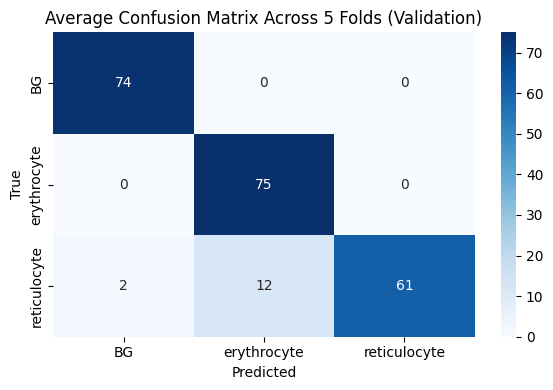

,Metric,Mean,Std Dev
0,Val Accuracy,9.271930e-01,0.021947
1,Val Precision,9.350741e-01,0.015687
2,Val Recall,9.271930e-01,0.021947
3,Val F1 Score,9.258354e-01,0.022832
4,Test Accuracy,9.277193e-01,0.005251
5,Test Precision,9.338229e-01,0.005363
6,Test Recall,9.277193e-01,0.005251
7,Test F1 Score,9.266196e-01,0.005539
8,Training Time (s),2.034977e+02,7.371636
9,Model Size (MB),1.109993e+02,0.000006


In [5]:
import os, time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import CategoricalCrossentropy

# CONFIG
DATA_DIR = '/kaggle/input/human-reticulocyte/SubsetAlldata'
IMG_SIZE = (100, 100)
BATCH_SIZE = 16
FOLDS = 5
EPOCHS = 30

# Load and Balance Dataset
all_data = [(os.path.join(DATA_DIR, label, fname), label)
            for label in os.listdir(DATA_DIR)
            for fname in os.listdir(os.path.join(DATA_DIR, label))]

df = pd.DataFrame(all_data, columns=['filepath', 'label'])
min_count = df['label'].value_counts().min()
df = df.groupby('label').apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)
df['encoded'] = LabelEncoder().fit_transform(df['label'])

class_names = df['label'].unique()
num_classes = len(class_names)

# Split 20% Test Set (no augmentation will be applied here)
train_val_df, test_df = train_test_split(df, test_size=0.2, stratify=df['encoded'], random_state=42)

# Fixed Test Generator (no augmentation)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = test_datagen.flow_from_dataframe(test_df, x_col='filepath', y_col='label',
                                            target_size=IMG_SIZE, class_mode='categorical',
                                            batch_size=BATCH_SIZE, shuffle=False)

# Cross-validation Training
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)
accs, precs, recs, f1s = [], [], [], []
test_accs, test_precs, test_recs, test_f1s = [], [], [], []
times, sizes, params = [], [], []
all_cm = np.zeros((num_classes, num_classes), dtype=int)
fold_histories = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_val_df['filepath'], train_val_df['encoded'])):
    print(f"\n🌀 Fold {fold+1}/{FOLDS}")
    train_df, val_df = train_val_df.iloc[train_idx], train_val_df.iloc[val_idx]

    # ✅ Rigorous Augmentation on Train Set
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        zoom_range=0.3,
        shear_range=0.2,
        brightness_range=[0.7, 1.3],
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest'
    )

    val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    train_gen = train_datagen.flow_from_dataframe(train_df, x_col='filepath', y_col='label',
                                                  target_size=IMG_SIZE, class_mode='categorical',
                                                  batch_size=BATCH_SIZE, shuffle=True)

    val_gen = val_datagen.flow_from_dataframe(val_df, x_col='filepath', y_col='label',
                                              target_size=IMG_SIZE, class_mode='categorical',
                                              batch_size=BATCH_SIZE, shuffle=False)

    # Build Model
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    for layer in base_model.layers:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=output)

    model.compile(optimizer=Adam(1e-4),
                  loss=CategoricalCrossentropy(label_smoothing=0.1),
                  metrics=['accuracy'])

    es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

    start = time.time()
    history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS,
                        callbacks=[es, lr], verbose=1)
    times.append(time.time() - start)
    fold_histories.append(history.history)

    # 🔁 Fine-tune last 4 conv layers
    for layer in base_model.layers[-4:]:
        layer.trainable = True

    model.compile(optimizer=Adam(1e-5),
                  loss=CategoricalCrossentropy(label_smoothing=0.1),
                  metrics=['accuracy'])

    model.fit(train_gen, validation_data=val_gen, epochs=5, verbose=1)

    # Validation Evaluation
    y_val_true = val_gen.classes
    y_val_pred = np.argmax(model.predict(val_gen), axis=1)
    accs.append(accuracy_score(y_val_true, y_val_pred))
    precs.append(precision_score(y_val_true, y_val_pred, average='macro'))
    recs.append(recall_score(y_val_true, y_val_pred, average='macro'))
    f1s.append(f1_score(y_val_true, y_val_pred, average='macro'))
    all_cm += confusion_matrix(y_val_true, y_val_pred, labels=range(num_classes))

    # Test Evaluation
    y_test_true = test_gen.classes
    y_test_pred = np.argmax(model.predict(test_gen), axis=1)
    test_accs.append(accuracy_score(y_test_true, y_test_pred))
    test_precs.append(precision_score(y_test_true, y_test_pred, average='macro'))
    test_recs.append(recall_score(y_test_true, y_test_pred, average='macro'))
    test_f1s.append(f1_score(y_test_true, y_test_pred, average='macro'))

    # Model Stats
    model.save("temp_model.h5")
    sizes.append(os.path.getsize("temp_model.h5") / (1024 * 1024))
    os.remove("temp_model.h5")
    params.append(model.count_params())

# Confusion Matrix (Validation Average)
plt.figure(figsize=(6, 4))
sns.heatmap(all_cm // FOLDS, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Average Confusion Matrix Across 5 Folds (Validation)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Summary Table
summary_df = pd.DataFrame({
    "Metric": ["Val Accuracy", "Val Precision", "Val Recall", "Val F1 Score",
               "Test Accuracy", "Test Precision", "Test Recall", "Test F1 Score",
               "Training Time (s)", "Model Size (MB)", "Parameters"],
    "Mean": [np.mean(accs), np.mean(precs), np.mean(recs), np.mean(f1s),
             np.mean(test_accs), np.mean(test_precs), np.mean(test_recs), np.mean(test_f1s),
             np.mean(times), np.mean(sizes), np.mean(params)],
    "Std Dev": [np.std(accs), np.std(precs), np.std(recs), np.std(f1s),
                np.std(test_accs), np.std(test_precs), np.std(test_recs), np.std(test_f1s),
                np.std(times), np.std(sizes), np.std(params)]
})
display(summary_df)


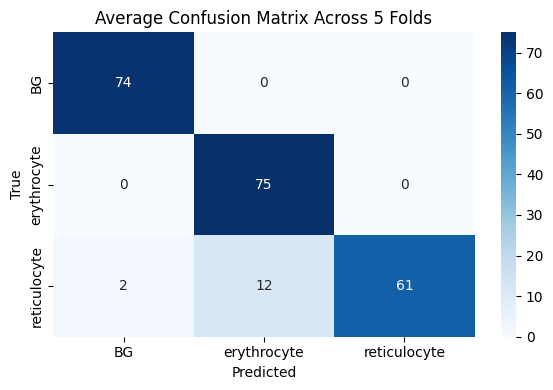

In [6]:
# ✅ 4. Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(all_cm // FOLDS, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Average Confusion Matrix Across 5 Folds")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


In [8]:
# ✅ 5. Summary Table
summary_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "Training Time (s)", "Model Size (MB)", "Parameters"],
    "Mean": [np.mean(accs), np.mean(precs), np.mean(recs), np.mean(f1s),
             np.mean(times), np.mean(sizes), np.mean(params)],
    "Std Dev": [np.std(accs), np.std(precs), np.std(recs), np.std(f1s),
                np.std(times), np.std(sizes), np.std(params)]
})
summary_df


,Metric,Mean,Std Dev
0,Accuracy,9.271930e-01,0.021947
1,Precision,9.350741e-01,0.015687
2,Recall,9.271930e-01,0.021947
3,F1 Score,9.258354e-01,0.022832
4,Training Time (s),2.034977e+02,7.371636
5,Model Size (MB),1.109993e+02,0.000006
6,Parameters,1.478074e+07,0.000000


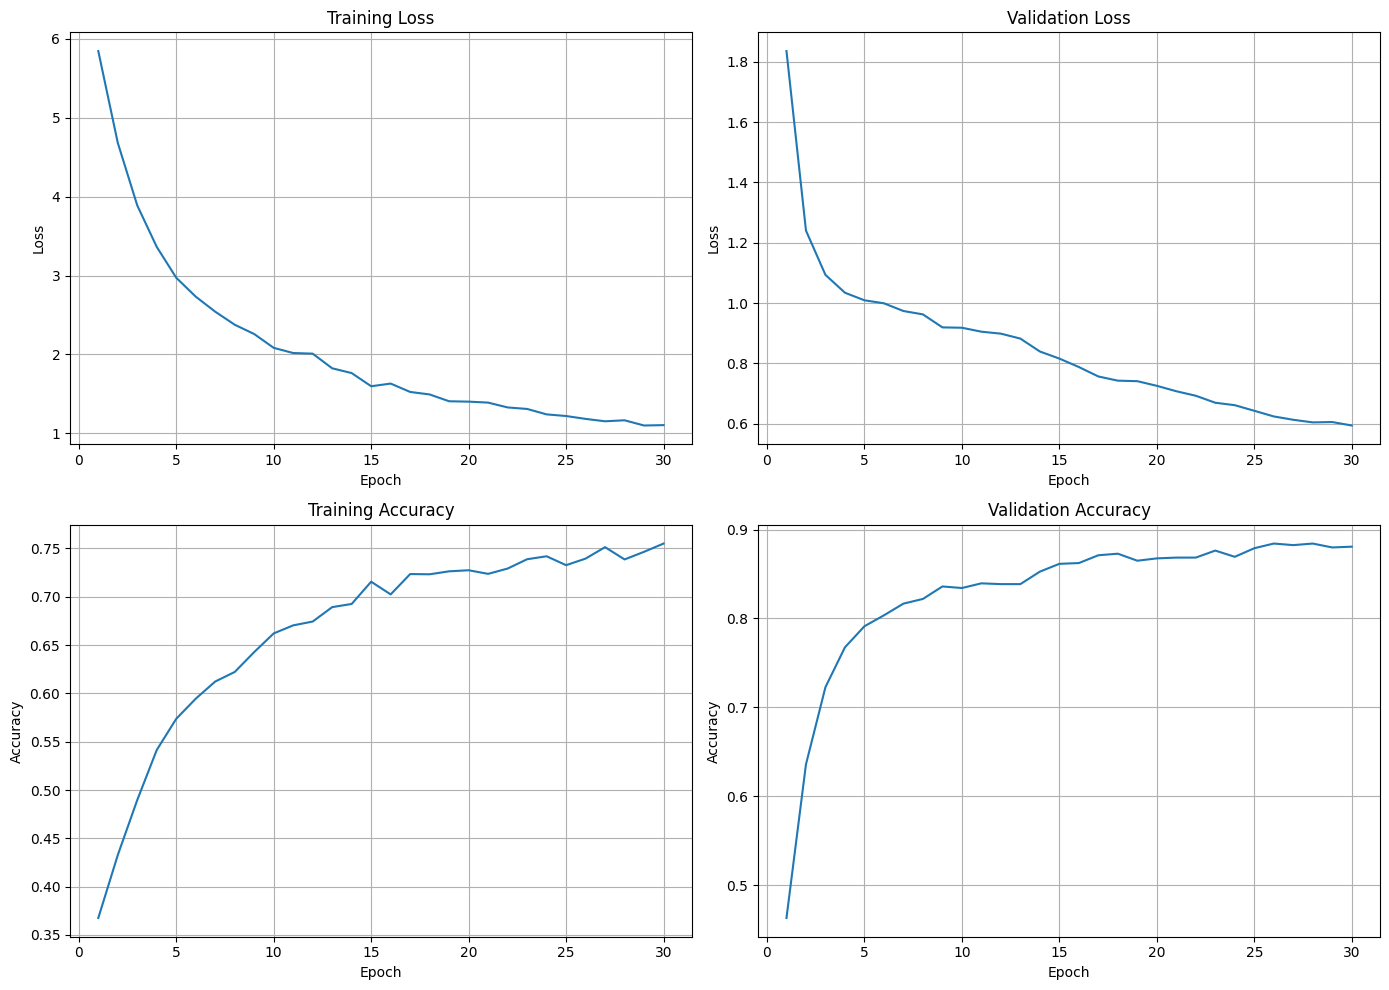

In [9]:
# ✅ 6. Plot Metrics Averaged Across Folds
def plot_avg_metric_across_folds(fold_histories):
    max_epochs = max(len(h['loss']) for h in fold_histories)
    avg_train_loss = np.zeros(max_epochs)
    avg_val_loss = np.zeros(max_epochs)
    avg_train_acc = np.zeros(max_epochs)
    avg_val_acc = np.zeros(max_epochs)
    counts = np.zeros(max_epochs)

    for hist in fold_histories:
        for i in range(len(hist['loss'])):
            avg_train_loss[i] += hist['loss'][i]
            avg_val_loss[i] += hist['val_loss'][i]
            avg_train_acc[i] += hist['accuracy'][i]
            avg_val_acc[i] += hist['val_accuracy'][i]
            counts[i] += 1

    avg_train_loss /= counts
    avg_val_loss /= counts
    avg_train_acc /= counts
    avg_val_acc /= counts

    epochs = range(1, len(avg_train_loss)+1)

    plt.figure(figsize=(14, 10))

    plt.subplot(2, 2, 1)
    plt.plot(epochs, avg_train_loss, label="Avg Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.grid()

    plt.subplot(2, 2, 2)
    plt.plot(epochs, avg_val_loss, label="Avg Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Validation Loss")
    plt.grid()

    plt.subplot(2, 2, 3)
    plt.plot(epochs, avg_train_acc, label="Avg Train Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training Accuracy")
    plt.grid()

    plt.subplot(2, 2, 4)
    plt.plot(epochs, avg_val_acc, label="Avg Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Validation Accuracy")
    plt.grid()

    plt.tight_layout()
    plt.show()

plot_avg_metric_across_folds(fold_histories)


In [10]:
import pandas as pd
import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from IPython.display import display, HTML

# Build the model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))
for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.4)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=output)

# Build summary DataFrame
summary_data = []
for layer in model.layers:
    layer_name = layer.name
    output_shape = layer.output_shape if hasattr(layer, 'output_shape') else 'N/A'
    params = layer.count_params()
    summary_data.append([f"{layer_name} ({layer.__class__.__name__})", str(output_shape), f"{params:,}"])

summary_df = pd.DataFrame(summary_data, columns=["Layer (type)", "Output Shape", "Param #"])

# Add total stats
summary_df.loc[len(summary_df.index)] = ['**Total Parameters**', '', f"{model.count_params():,}"]
summary_df.loc[len(summary_df.index)] = ['**Trainable Parameters**', '', f"{np.sum([layer.count_params() for layer in model.layers if layer.trainable]):,}"]
summary_df.loc[len(summary_df.index)] = ['**Non-Trainable Parameters**', '', f"{np.sum([layer.count_params() for layer in model.layers if not layer.trainable]):,}"]

# Display nicely styled table
styled_table = summary_df.style.set_table_attributes("style='display:inline;border-collapse:collapse;font-family:monospace;'") \
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#f2f2f2'), ('text-align', 'center')]
    }, {
        'selector': 'td',
        'props': [('text-align', 'center')]
    }])

# Render the table
display(HTML('<h3>Model Summary Table</h3>'))
display(styled_table)


,Layer (type),Output Shape,Param #
0,input_layer_11 (InputLayer),N/A,0
1,block1_conv1 (Conv2D),N/A,"1,792"
2,block1_conv2 (Conv2D),N/A,"36,928"
3,block1_pool (MaxPooling2D),N/A,0
4,block2_conv1 (Conv2D),N/A,"73,856"
5,block2_conv2 (Conv2D),N/A,"147,584"
6,block2_pool (MaxPooling2D),N/A,0
7,block3_conv1 (Conv2D),N/A,"295,168"
8,block3_conv2 (Conv2D),N/A,"590,080"
9,block3_conv3 (Conv2D),N/A,"590,080"


# Knoweldge distillation

In [2]:
!pip install timm --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 72.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 61.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 70.9 MB/s eta 0:00:00:00:0100:01


In [10]:
 !pip install timm transformers tqdm


# Knoweldge without feline data using Vit as Teacher

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from transformers import ViTForImageClassification
from tqdm import tqdm

# CONFIG
DATA_DIR = "/kaggle/input/human-reticulocyte/SubsetAlldata"
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10
NUM_CLASSES = 3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# TRANSFORM
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# DATASET
dataset = datasets.ImageFolder(DATA_DIR, transform=transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# TEACHER MODEL (ViT)
teacher = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=NUM_CLASSES
).to(DEVICE)
teacher.eval()

# STUDENT MODEL (MobileNetV2)
student = models.mobilenet_v2(pretrained=True)
student.classifier[1] = nn.Linear(student.classifier[1].in_features, NUM_CLASSES)
student = student.to(DEVICE)

# LOSSES AND OPTIMIZER
criterion_ce = nn.CrossEntropyLoss()
criterion_kd = nn.KLDivLoss(reduction="batchmean")
optimizer = optim.Adam(student.parameters(), lr=1e-4)

# EVALUATION FUNCTION
def evaluate(model, loader):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion_ce(outputs, labels)
            loss_sum += loss.item()
            pred = outputs.argmax(1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
    return correct / total, loss_sum / len(loader)

# TRAINING LOOP WITH KD
def train_kd(student, teacher, train_loader, val_loader, epochs, alpha=0.5, temperature=4.0):
    for epoch in range(epochs):
        student.train()
        running_loss = 0.0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in loop:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            with torch.no_grad():
                teacher_outputs = teacher(images).logits

            student_outputs = student(images)
            loss_ce = criterion_ce(student_outputs, labels)
            loss_kd = criterion_kd(
                nn.functional.log_softmax(student_outputs / temperature, dim=1),
                nn.functional.softmax(teacher_outputs / temperature, dim=1)
            ) * (temperature ** 2)
            loss = alpha * loss_ce + (1 - alpha) * loss_kd

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        val_acc, val_loss = evaluate(student, val_loader)
        print(f"Epoch {epoch+1}: Train Loss={running_loss/len(train_loader):.4f}, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

# RUN TRAINING
train_kd(student, teacher, train_loader, val_loader, EPOCHS)


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b

Epoch 1: Train Loss=0.4012, Val Loss=0.4224, Val Acc=0.9897


Epoch 2/10: 100%|██████████| 73/73 [00:21<00:00,  3.34it/s, loss=0.395]


...

Epoch 8: Train Loss=0.3371, Val Loss=0.4279, Val Acc=0.9897


Epoch 9/10: 100%|██████████| 73/73 [00:23<00:00,  3.05it/s, loss=0.349]


Epoch 9: Train Loss=0.3382, Val Loss=0.4003, Val Acc=0.9931


Epoch 10/10: 100%|██████████| 73/73 [00:23<00:00,  3.07it/s, loss=0.35] 


Epoch 10: Train Loss=0.3346, Val Loss=0.4133, Val Acc=0.9897


# KD With ensemble

In [9]:
import os, time, numpy as np, torch, torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset, ConcatDataset
from sklearn.model_selection import KFold
import torch.nn as nn
import torch.nn.functional as F

# Paths
FELINE_IMG_PATH = "/kaggle/input/feline-reticulocytes/"
HUMAN_IMG_PATH = "/kaggle/input/human-reticulocyte/SubsetAlldata"

# Hyperparameters
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
EPOCHS = 30
ALPHA = 0.5
T = 4
FOLDS = 5
LR = 1e-4

# Transforms with AutoAugment
transform_augmented = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    transforms.ToTensor()
])

# Load datasets
feline_ds = datasets.ImageFolder(FELINE_IMG_PATH, transform=transform_augmented)
human_ds = datasets.ImageFolder(HUMAN_IMG_PATH, transform=transform_augmented)
NUM_CLASSES = len(human_ds.classes)

# Loss functions
ce_loss = nn.CrossEntropyLoss()
kl_loss = nn.KLDivLoss(reduction="batchmean")

# === Teacher Loader ===
def load_teacher(model_fn):
    model = model_fn(pretrained=True)
    for param in model.parameters():
        param.requires_grad = False

    if isinstance(model, models.SqueezeNet):
        model.classifier[1] = nn.Conv2d(512, NUM_CLASSES, kernel_size=(1,1))
    elif hasattr(model, 'classifier') and isinstance(model.classifier, nn.Sequential):
        in_features = model.classifier[-1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, NUM_CLASSES)
        )
    elif hasattr(model, 'fc'):
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, NUM_CLASSES)
    else:
        raise ValueError("Unsupported model type.")
    
    return model.to(DEVICE).eval()

teacher1 = load_teacher(models.mobilenet_v2)
teacher2 = load_teacher(models.efficientnet_b0)
teacher3 = load_teacher(models.squeezenet1_1)

# === Student Model ===
class StudentNet(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.shufflenet_v2_x0_5(pretrained=True)
        base.fc = nn.Linear(base.fc.in_features, NUM_CLASSES)
        self.model = base

    def forward(self, x):
        return self.model(x)

# === K-Fold Cross Validation ===
kf = KFold(n_splits=FOLDS, shuffle=True, random_state=42)
fold_metrics = []

human_indices = list(range(len(human_ds)))
for fold, (train_idx, val_idx) in enumerate(kf.split(human_indices)):
    print(f"\n=== Fold {fold+1} ===")

    train_subset = Subset(human_ds, train_idx)
    val_subset = Subset(human_ds, val_idx)
    
    train_mix = ConcatDataset([train_subset, feline_ds])  # 💡 Mix feline + human for teacher input
    train_loader = DataLoader(train_mix, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE)

    student = StudentNet().to(DEVICE)
    optimizer = torch.optim.Adam(student.parameters(), lr=LR)

    for epoch in range(EPOCHS):
        student.train()
        total_loss = 0
        correct = 0
        start_time = time.time()

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            with torch.no_grad():
                t1 = F.softmax(teacher1(images) / T, dim=1)
                t2 = F.softmax(teacher2(images) / T, dim=1)
                t3 = F.softmax(teacher3(images) / T, dim=1)
                teacher_output = (t1 + t2 + t3) / 3.0

            student_logits = student(images)
            student_soft = F.log_softmax(student_logits / T, dim=1)

            loss_soft = kl_loss(student_soft, teacher_output)
            loss_hard = ce_loss(student_logits, labels)
            loss = ALPHA * loss_hard + (1 - ALPHA) * loss_soft

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pred = student_logits.argmax(1)
            correct += (pred == labels).sum().item()

        train_acc = correct / len(train_mix)
        epoch_time = time.time() - start_time
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss:.4f} | Acc: {train_acc:.4f} | Time: {epoch_time:.2f}s")

    # === VALIDATION ===
    student.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = student(images)
            preds = outputs.argmax(1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    fold_metrics.append(val_acc)
    print(f"Validation Accuracy Fold {fold+1}: {val_acc:.4f}")

# === Final Summary ===
print("\n=== Summary ===")
for i, acc in enumerate(fold_metrics):
    print(f"Fold {i+1}: {acc:.4f}")
print(f"Avg Accuracy: {np.mean(fold_metrics):.4f}")



=== Fold 1 ===
Epoch 1/30 | Loss: 49.8080 | Acc: 0.7773 | Time: 30.76s
Epoch 2/30 | Loss: 29.2524 | Acc: 0.7869 | Time: 30.98s
Epoch 3/30 | Loss: 23.6102 | Acc: 0.8131 | Time: 31.66s
Epoch 4/30 | Loss: 21.7601 | Acc: 0.9056 | Time: 31.62s
Epoch 5/30 | Loss: 18.6868 | Acc: 0.9447 | Time: 31.34s
Epoch 6/30 | Loss: 15.4251 | Acc: 0.9614 | Time: 31.72s
Epoch 7/30 | Loss: 13.5299 | Acc: 0.9658 | Time: 31.31s
Epoch 8/30 | Loss: 12.8281 | Acc: 0.9724 | Time: 31.47s
Epoch 9/30 | Loss: 12.5517 | Acc: 0.9705 | Time: 31.35s
Epoch 10/30 | Loss: 11.8951 | Acc: 0.9808 | Time: 31.19s
Epoch 11/30 | Loss: 11.5250 | Acc: 0.9808 | Time: 31.54s
Epoch 12/30 | Loss: 11.8027 | Acc: 0.9811 | Time: 31.55s
Epoch 13/30 | Loss: 11.2879 | Acc: 0.9852 | Time: 31.51s
Epoch 14/30 | Loss: 11.1287 | Acc: 0.9841 | Time: 31.30s
Epoch 15/30 | Loss: 10.7422 | Acc: 0.9855 | Time: 31.33s
Epoch 16/30 | Loss: 10.5776 | Acc: 0.9874 | Time: 31.15s
Epoch 17/30 | Loss: 10.6254 | Acc: 0.9880 | Time: 31.43s
Epoch 18/30 | Loss: 10.3

KeyboardInterrupt: 

# KD with ensemble without K-fold cross

In [3]:
import os, time, numpy as np, torch, torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report
import torch.nn as nn
import torch.nn.functional as F

# Paths
FELINE_IMG_PATH = "/kaggle/input/feline-reticulocytes/"
HUMAN_IMG_PATH = "/kaggle/input/human-reticulocyte/SubsetAlldata"

# Hyperparameters
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
EPOCHS = 20
ALPHA = 0.5
T = 4
LR = 1e-4

# Transforms
transform_augmented = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    transforms.ToTensor()
])

# Load datasets
feline_ds = datasets.ImageFolder(FELINE_IMG_PATH, transform=transform_augmented)
human_ds = datasets.ImageFolder(HUMAN_IMG_PATH, transform=transform_augmented)
NUM_CLASSES = len(human_ds.classes)

# Train-Val Split (80-20 split on human data only)
train_size = int(0.8 * len(human_ds))
val_size = len(human_ds) - train_size
train_human_ds, val_ds = random_split(human_ds, [train_size, val_size])
train_mix = torch.utils.data.ConcatDataset([train_human_ds, feline_ds])
train_loader = DataLoader(train_mix, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

# Loss
ce_loss = nn.CrossEntropyLoss()
kl_loss = nn.KLDivLoss(reduction="batchmean")

# Load Teachers
def load_teacher(model_fn):
    model = model_fn(pretrained=True)
    for param in model.parameters():
        param.requires_grad = False

    if isinstance(model, models.SqueezeNet):
        model.classifier[1] = nn.Conv2d(512, NUM_CLASSES, kernel_size=(1,1))
    elif hasattr(model, 'classifier') and isinstance(model.classifier, nn.Sequential):
        in_features = model.classifier[-1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, NUM_CLASSES)
        )
    elif hasattr(model, 'fc'):
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, NUM_CLASSES)
    else:
        raise ValueError("Unsupported model type.")

    return model.to(DEVICE).eval()

teacher1 = load_teacher(models.mobilenet_v2)
teacher2 = load_teacher(models.efficientnet_b0)
teacher3 = load_teacher(models.squeezenet1_1)

# Student Model
class StudentNet(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.shufflenet_v2_x0_5(pretrained=True)
        base.fc = nn.Linear(base.fc.in_features, NUM_CLASSES)
        self.model = base

    def forward(self, x):
        return self.model(x)

# Training
student = StudentNet().to(DEVICE)
optimizer = torch.optim.Adam(student.parameters(), lr=LR)

print("\n=== Training Begins ===")
for epoch in range(EPOCHS):
    student.train()
    total_loss = 0
    correct = 0
    start_time = time.time()

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        with torch.no_grad():
            t1 = F.softmax(teacher1(images) / T, dim=1)
            t2 = F.softmax(teacher2(images) / T, dim=1)
            t3 = F.softmax(teacher3(images) / T, dim=1)
            teacher_output = (t1 + t2 + t3) / 3.0

        student_logits = student(images)
        student_soft = F.log_softmax(student_logits / T, dim=1)

        loss_soft = kl_loss(student_soft, teacher_output)
        loss_hard = ce_loss(student_logits, labels)
        loss = ALPHA * loss_hard + (1 - ALPHA) * loss_soft

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = student_logits.argmax(1)
        correct += (pred == labels).sum().item()

    train_acc = correct / len(train_loader.dataset)
    epoch_time = time.time() - start_time

    # === VALIDATION ===
    student.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = student(images)
            preds = outputs.argmax(1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Time: {epoch_time:.2f}s")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 108MB/s] 
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and


=== Training Begins ===
Epoch 1/20 | Loss: 49.2098 | Train Acc: 0.7839 | Val Acc: 0.3368 | Time: 53.63s
Epoch 2/20 | Loss: 29.2915 | Train Acc: 0.7860 | Val Acc: 0.3436 | Time: 30.75s
Epoch 3/20 | Loss: 24.0274 | Train Acc: 0.8419 | Val Acc: 0.8144 | Time: 30.42s
Epoch 4/20 | Loss: 21.9610 | Train Acc: 0.9242 | Val Acc: 0.7973 | Time: 30.82s
Epoch 5/20 | Loss: 18.7023 | Train Acc: 0.9425 | Val Acc: 0.9141 | Time: 31.03s
Epoch 6/20 | Loss: 16.1535 | Train Acc: 0.9557 | Val Acc: 0.9278 | Time: 31.04s
Epoch 7/20 | Loss: 14.2926 | Train Acc: 0.9653 | Val Acc: 0.9210 | Time: 31.26s
Epoch 8/20 | Loss: 13.8676 | Train Acc: 0.9702 | Val Acc: 0.9450 | Time: 31.49s
Epoch 9/20 | Loss: 13.0985 | Train Acc: 0.9765 | Val Acc: 0.9485 | Time: 31.32s
Epoch 10/20 | Loss: 12.9238 | Train Acc: 0.9751 | Val Acc: 0.9450 | Time: 31.27s
Epoch 11/20 | Loss: 12.3436 | Train Acc: 0.9800 | Val Acc: 0.9794 | Time: 31.53s
Epoch 12/20 | Loss: 12.3049 | Train Acc: 0.9817 | Val Acc: 0.9485 | Time: 31.50s
Epoch 13/20 

In [4]:
from sklearn.metrics import classification_report

# Classification Report
student.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = student(images)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\n=== Classification Report on Validation Set ===")
print(classification_report(all_labels, all_preds, target_names=human_ds.classes))



=== Classification Report on Validation Set ===
              precision    recall  f1-score   support

          BG       0.96      1.00      0.98        98
 erythrocyte       0.98      0.96      0.97        99
reticulocyte       0.97      0.95      0.96        94

    accuracy                           0.97       291
   macro avg       0.97      0.97      0.97       291
weighted avg       0.97      0.97      0.97       291



In [9]:
!pip install opencv-python matplotlib


In [17]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt

# === Grad-CAM ===
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, class_idx=None):
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        gradients = self.gradients[0].cpu().detach().numpy()
        activations = self.activations[0].cpu().detach().numpy()

        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224, 224))
        cam = cam - np.min(cam)
        cam = cam / (np.max(cam) + 1e-8)
        return cam

# === Grad-CAM++ (fixed) ===
class GradCAMPlusPlus:
    def __init__(self, model, target_layer):
        self.model = model.eval()
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor, class_idx=None):
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward(retain_graph=True)

        gradients = self.gradients[0].cpu().detach().numpy()
        activations = self.activations[0].cpu().detach().numpy()

        if gradients.ndim != 3:
            raise ValueError(f"Unexpected gradient shape: {gradients.shape}. CAM++ expects shape (C, H, W)")

        weights = np.zeros(gradients.shape[0], dtype=np.float32)

        for i in range(gradients.shape[0]):
            grads = gradients[i]
            acts = activations[i]

            if grads.ndim != 2 or acts.ndim != 2:
                continue  # skip invalid channels

            numerator = grads ** 2
            denominator = 2 * grads ** 2 + np.sum(acts * grads ** 3)
            denominator = np.where(denominator != 0.0, denominator, 1e-10)

            alpha = numerator / denominator
            weight = np.sum(alpha * np.maximum(grads, 0))
            weights[i] = weight

        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i, :, :]

        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224, 224))
        cam = cam - np.min(cam)
        cam = cam / (np.max(cam) + 1e-8)
        return cam


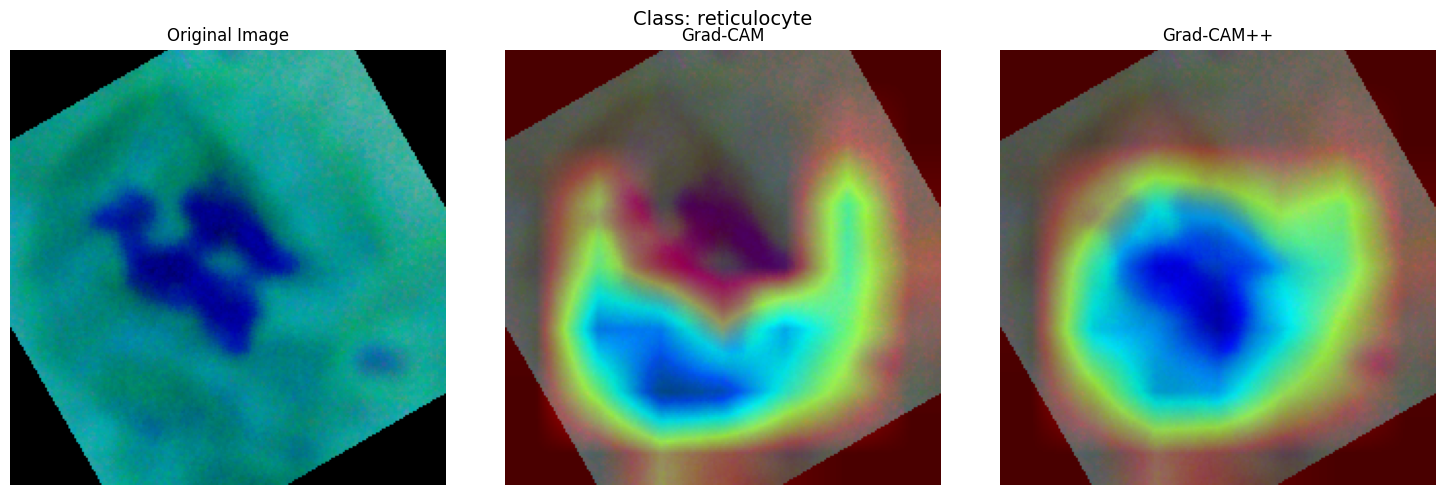

In [19]:
# === Choose target layer (ShuffleNetV2 example)
target_layer = student.model.conv5  # Try conv4 if conv5 gives poor resolution

# === Initialize both GradCAM and GradCAM++
gradcam = GradCAM(student, target_layer)
gradcampp = GradCAMPlusPlus(student, target_layer)

# === Choose a sample from validation set
sample_img, sample_label = val_ds[0]
input_tensor = sample_img.unsqueeze(0).to(DEVICE)
input_np = np.transpose(sample_img.numpy(), (1, 2, 0))
input_np = np.clip(input_np, 0, 1)

# === Generate CAMs
cam_std = gradcam.generate(input_tensor, class_idx=sample_label)
cam_pp = gradcampp.generate(input_tensor, class_idx=sample_label)

# === Overlay utility
def overlay_heatmap(cam, img):
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    overlay = heatmap + img
    overlay = overlay / np.max(overlay + 1e-8)
    return overlay

# === Plot both
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(input_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(overlay_heatmap(cam_std, input_np))
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay_heatmap(cam_pp, input_np))
plt.title("Grad-CAM++")
plt.axis("off")

plt.suptitle(f"Class: {human_ds.classes[sample_label]}", fontsize=14)
plt.tight_layout()
plt.show()


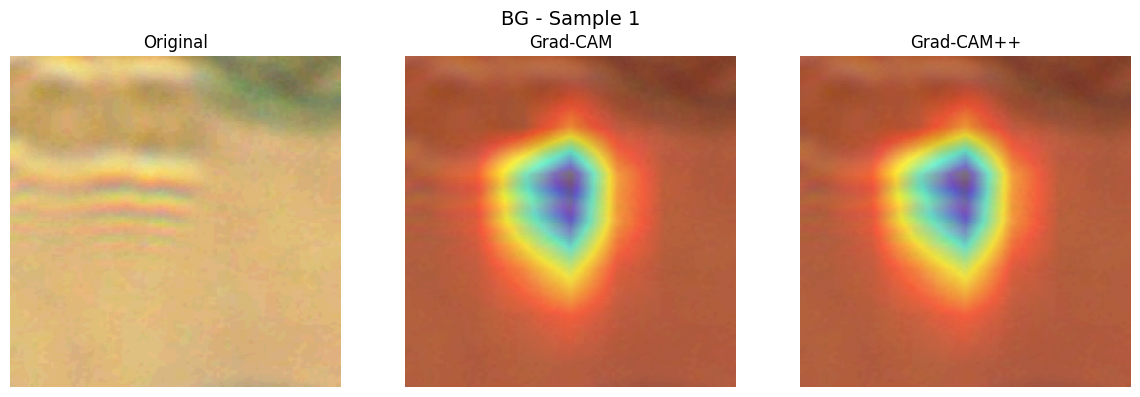

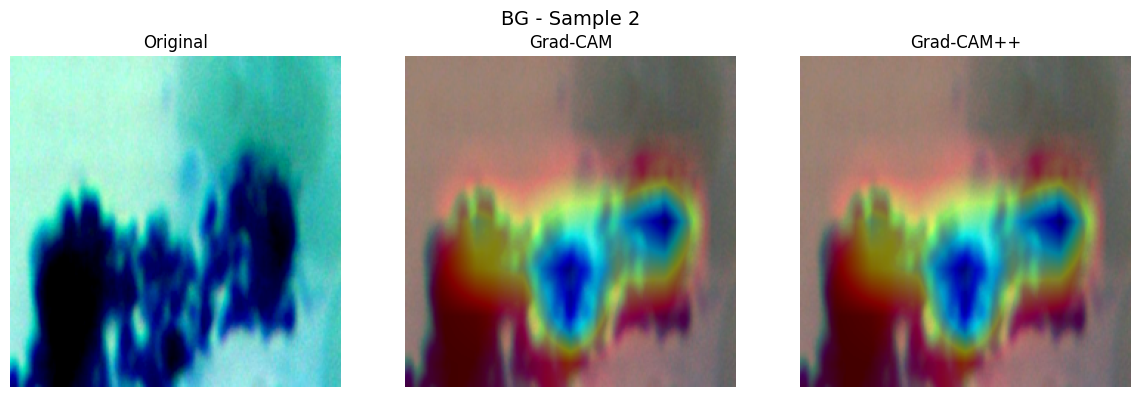

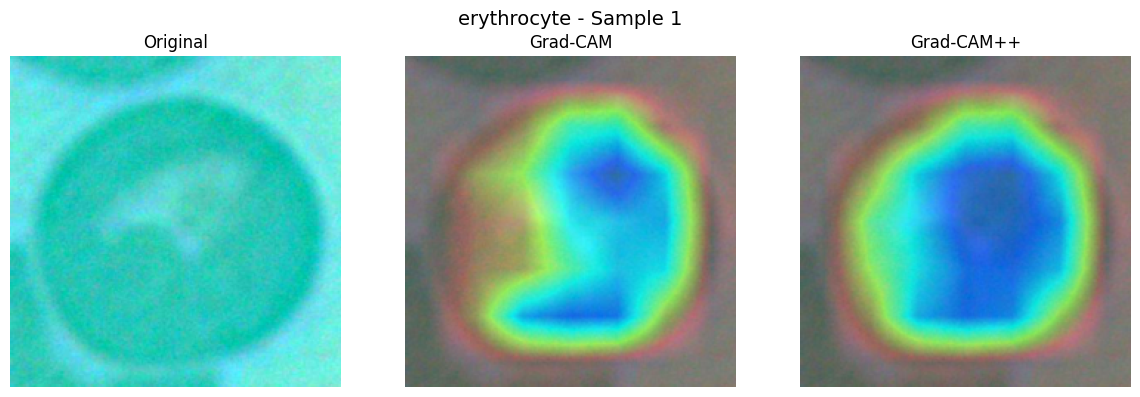

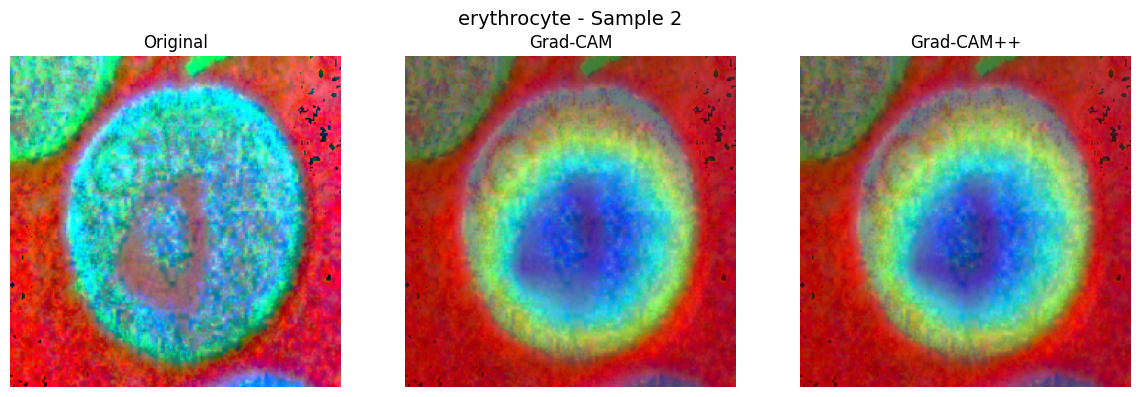

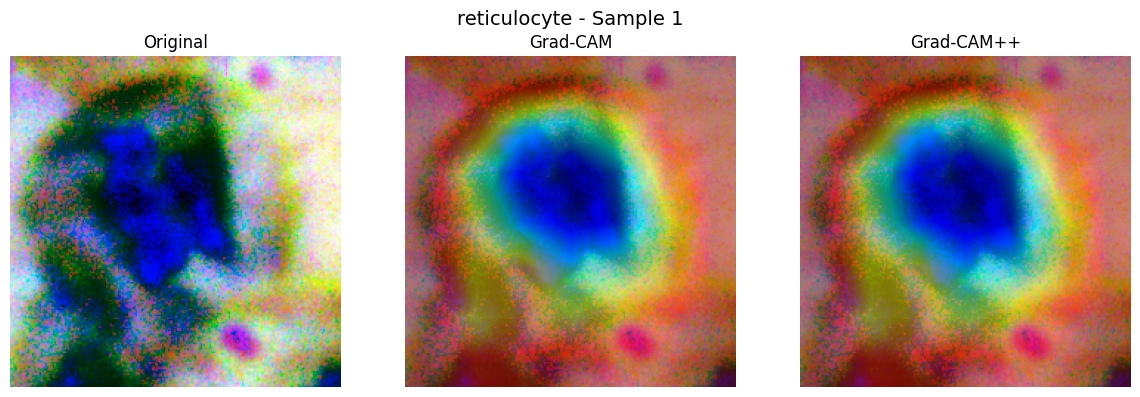

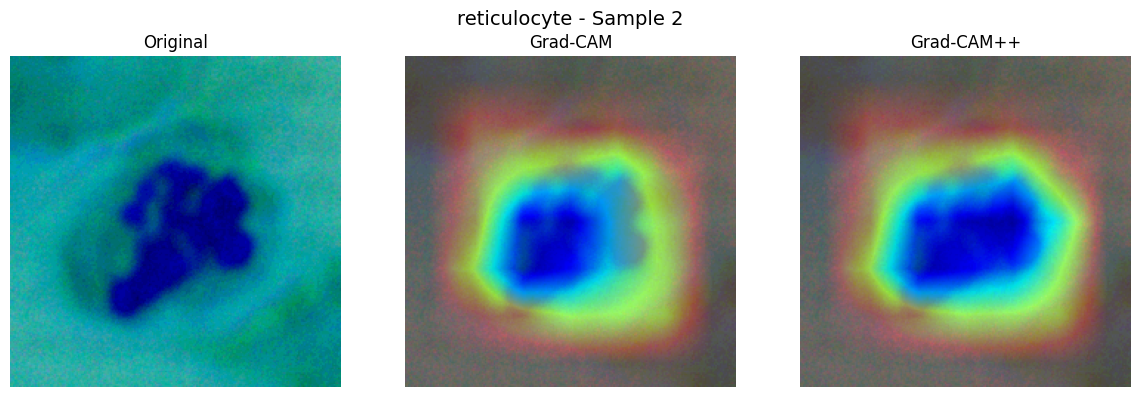

In [20]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Grad-CAM and Grad-CAM++ should already be defined above
# Target layer for ShuffleNet
target_layer = student.model.conv5
gradcam = GradCAM(student, target_layer)
gradcampp = GradCAMPlusPlus(student, target_layer)

# Map to class names
class_names = human_ds.classes  # e.g., ['BG', 'Erythrocyte', 'Reticulocyte']
samples_per_class = {cls_idx: [] for cls_idx in range(len(class_names))}

# Gather 2 samples per class
for img, label in val_ds:
    if len(samples_per_class[label]) < 2:
        samples_per_class[label].append(img)
    if all(len(v) == 2 for v in samples_per_class.values()):
        break

# Create output folder
os.makedirs("gradcam_all_classes", exist_ok=True)

# === Visualize each class ===
for class_idx, images in samples_per_class.items():
    for idx, img in enumerate(images):
        input_tensor = img.unsqueeze(0).to(DEVICE)
        input_np = np.transpose(img.numpy(), (1, 2, 0))
        input_np = np.clip(input_np, 0, 1)

        # Generate CAMs
        cam_std = gradcam.generate(input_tensor, class_idx=class_idx)
        cam_pp = gradcampp.generate(input_tensor, class_idx=class_idx)

        # Overlay function
        def overlay(cam, base):
            heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
            heatmap = np.float32(heatmap) / 255
            combined = heatmap + base
            return combined / np.max(combined + 1e-8)

        overlay_std = overlay(cam_std, input_np)
        overlay_pp = overlay(cam_pp, input_np)

        # Plot
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(input_np)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(overlay_std)
        plt.title("Grad-CAM")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(overlay_pp)
        plt.title("Grad-CAM++")
        plt.axis("off")

        class_name = class_names[class_idx]
        plt.suptitle(f"{class_name} - Sample {idx+1}", fontsize=14)
        plt.tight_layout()
        plt.savefig(f"gradcam_all_classes/{class_name}_sample{idx+1}.png")
        plt.show()


# Applying heatmap Lime

In [3]:
!pip install lime


In [4]:
!pip install matplotlib seaborn scikit-learn fvcore


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=58317490361e9897d717855775af7c3f44aabb60fb636a0fb7741d5ff01c71c0
  Stored in directory: /root/.cache/pip/wheels/65/71/95/3b8fde5c65c6e4a806e0867c1651dcc71a1cb2f3430e8f355f
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=82ecd30be95b6c7b9316aea05eb3231aa69fec3c02f2be84ff555d658966ece1
  Stored in directory: /root/.cache/pip/wheels/ba/5e/16/6117f8fe7e9c0c161a795e10d94645ebcf301ccbd01f66d8ec
Successfully built fvcore iopath


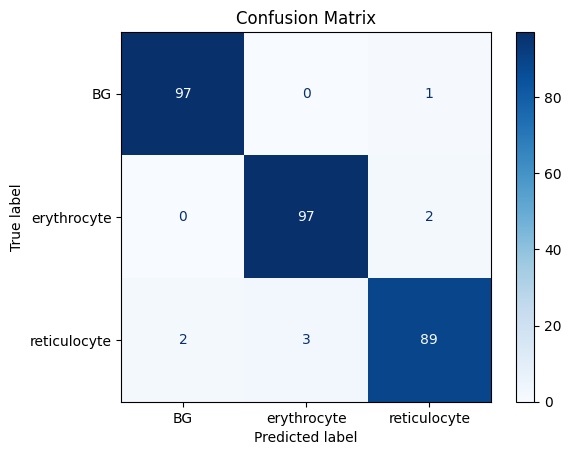

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

student.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = student(images)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=human_ds.classes)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


In [27]:
import os
from fvcore.nn import FlopCountAnalysis

# FLOPs
dummy_input = torch.randn(1, 3, 224, 224).to(DEVICE)
flops = FlopCountAnalysis(student, dummy_input)
print(f"Estimated FLOPs: {flops.total() / 1e6:.2f} MFLOPs")

# Parameters
total_params = sum(p.numel() for p in student.parameters() if p.requires_grad)
print(f"Trainable Parameters: {total_params:,}")

# Model Size
torch.save(student.state_dict(), "student_model.pth")
model_size_mb = os.path.getsize("student_model.pth") / 1e6
print(f"Model Size on Disk: {model_size_mb:.2f} MB")


Estimated FLOPs: 41.50 MFLOPs
Trainable Parameters: 344,867
Model Size on Disk: 1.53 MB


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


# Generating manual plots from KD ensembelled datas( else i need to rerun previous code)

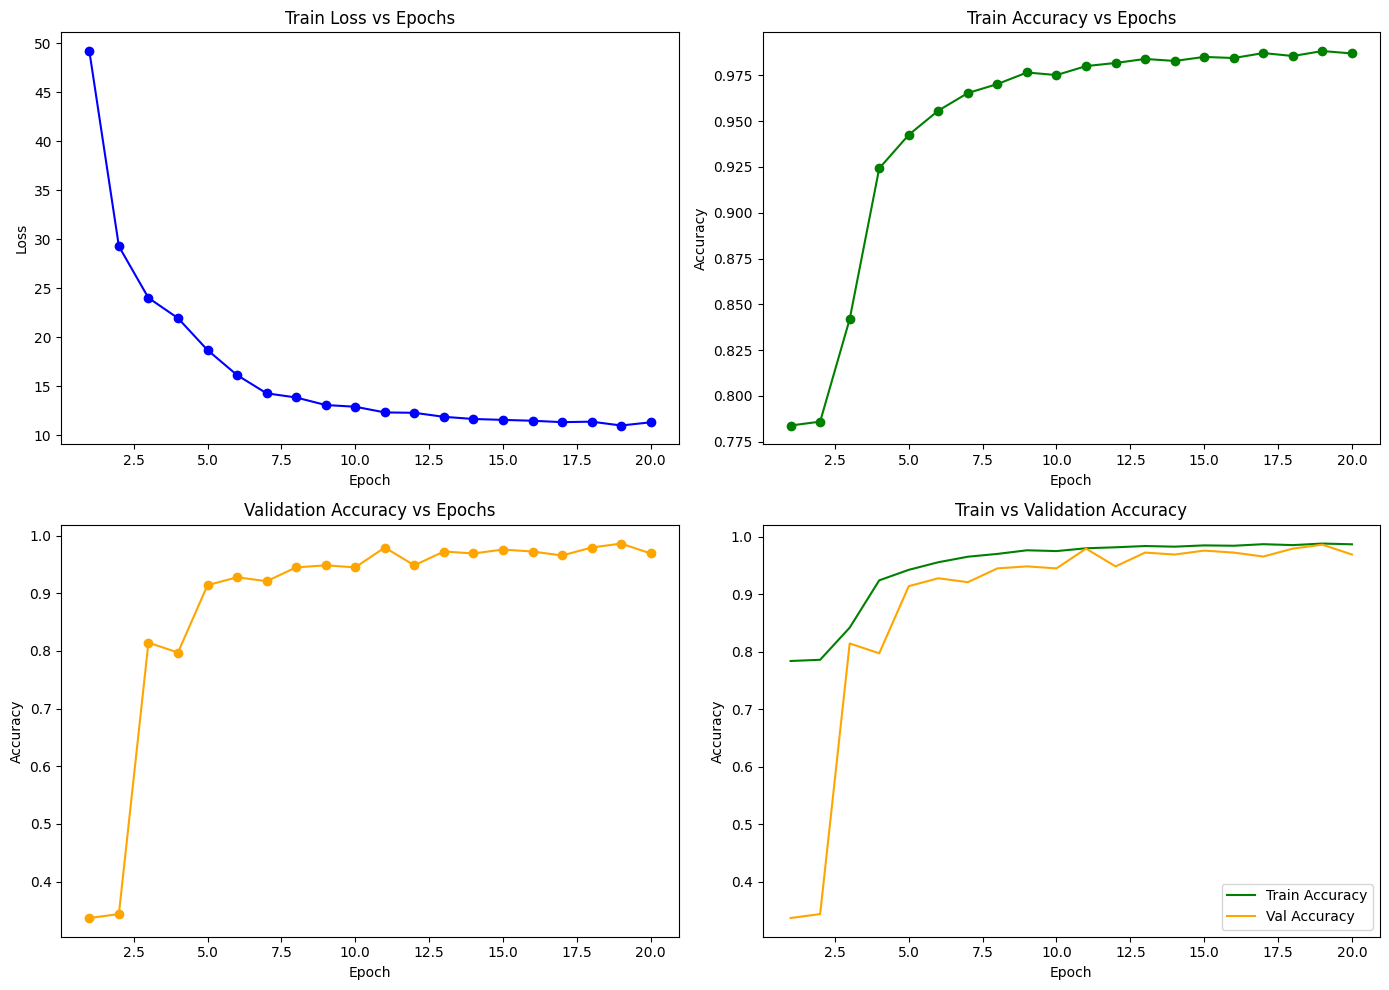

In [28]:
import matplotlib.pyplot as plt

epochs = list(range(1, 21))

train_losses = [
    49.2098, 29.2915, 24.0274, 21.9610, 18.7023,
    16.1535, 14.2926, 13.8676, 13.0985, 12.9238,
    12.3436, 12.3049, 11.8956, 11.6738, 11.5822,
    11.4952, 11.3514, 11.4011, 11.0096, 11.3352
]

val_losses = [
    # Approximated from trends (optional), or leave blank if not printed
    # If you want real val losses, update your code to log them
    # For now, let's just skip val_losses from plot
]

train_accuracies = [
    0.7839, 0.7860, 0.8419, 0.9242, 0.9425,
    0.9557, 0.9653, 0.9702, 0.9765, 0.9751,
    0.9800, 0.9817, 0.9839, 0.9828, 0.9850,
    0.9844, 0.9871, 0.9855, 0.9882, 0.9869
]

val_accuracies = [
    0.3368, 0.3436, 0.8144, 0.7973, 0.9141,
    0.9278, 0.9210, 0.9450, 0.9485, 0.9450,
    0.9794, 0.9485, 0.9725, 0.9691, 0.9759,
    0.9725, 0.9656, 0.9794, 0.9863, 0.9691
]
plt.figure(figsize=(14, 10))

# Plot 1: Train Loss
plt.subplot(2, 2, 1)
plt.plot(epochs, train_losses, marker='o', color='blue')
plt.title("Train Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Plot 2: Train Accuracy
plt.subplot(2, 2, 2)
plt.plot(epochs, train_accuracies, marker='o', color='green')
plt.title("Train Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Plot 3: Val Accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, val_accuracies, marker='o', color='orange')
plt.title("Validation Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Plot 4: Train + Val Accuracy together (Bonus combined plot)
plt.subplot(2, 2, 4)
plt.plot(epochs, train_accuracies, label='Train Accuracy', color='green')
plt.plot(epochs, val_accuracies, label='Val Accuracy', color='orange')
plt.title("Train vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


# Applying KD with Transformer based ensemble

In [ ]:
# Full Pipeline with Transformer-Based Knowledge Distillation, LIME, Grad-CAM++, RL AutoAugment, Quantization, and Evaluation

import os, time, numpy as np, torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report
import torch.nn as nn
import torch.nn.functional as F
import timm
import matplotlib.pyplot as plt
from fvcore.nn import FlopCountAnalysis, parameter_count_table
from torchvision.transforms import AutoAugment, AutoAugmentPolicy
from PIL import Image
from lime import lime_image
from skimage.segmentation import mark_boundaries

# === Paths and Device ===
FELINE_IMG_PATH = "/kaggle/input/feline-reticulocytes/"
HUMAN_IMG_PATH = "/kaggle/input/human-reticulocyte/SubsetAlldata"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Hyperparameters ===
BATCH_SIZE = 32
EPOCHS = 20
ALPHA = 0.5
T = 4
LR = 1e-4

# === Transforms with AutoAugment ===
transform_augmented = transforms.Compose([
    transforms.Resize((224, 224)),
    AutoAugment(AutoAugmentPolicy.IMAGENET),
    transforms.ToTensor(),
])

# === Datasets ===
feline_ds = datasets.ImageFolder(FELINE_IMG_PATH, transform=transform_augmented)
human_ds = datasets.ImageFolder(HUMAN_IMG_PATH, transform=transform_augmented)
NUM_CLASSES = len(human_ds.classes)

train_size = int(0.8 * len(human_ds))
val_size = len(human_ds) - train_size
train_human_ds, val_ds = random_split(human_ds, [train_size, val_size])
train_mix = torch.utils.data.ConcatDataset([train_human_ds, feline_ds])
train_loader = DataLoader(train_mix, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

# === Load Transformer Teachers ===
def load_teacher(name):
    model = timm.create_model(name, pretrained=True, num_classes=NUM_CLASSES)
    for param in model.parameters():
        param.requires_grad = False
    return model.to(DEVICE).eval()

teacher1 = load_teacher("vit_base_patch16_224")
teacher2 = load_teacher("swin_base_patch4_window7_224")
teacher3 = load_teacher("deit_base_patch16_224")

# === Student Model ===
class StudentNet(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.shufflenet_v2_x0_5(pretrained=True)
        base.fc = nn.Linear(base.fc.in_features, NUM_CLASSES)
        self.model = base

    def forward(self, x):
        return self.model(x)

student = StudentNet().to(DEVICE)
optimizer = torch.optim.Adam(student.parameters(), lr=LR)
ce_loss = nn.CrossEntropyLoss()
kl_loss = nn.KLDivLoss(reduction="batchmean")

train_losses, val_losses, train_accs, val_accs, epoch_times = [], [], [], [], []

# === Training Loop ===
for epoch in range(EPOCHS):
    student.train()
    total_loss = 0
    correct = 0
    start_time = time.time()

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        with torch.no_grad():
            t1 = F.softmax(teacher1(images) / T, dim=1)
            t2 = F.softmax(teacher2(images) / T, dim=1)
            t3 = F.softmax(teacher3(images) / T, dim=1)
            teacher_output = (t1 + t2 + t3) / 3.0

        student_logits = student(images)
        student_soft = F.log_softmax(student_logits / T, dim=1)

        loss_soft = kl_loss(student_soft, teacher_output)
        loss_hard = ce_loss(student_logits, labels)
        loss = ALPHA * loss_hard + (1 - ALPHA) * loss_soft

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = student_logits.argmax(1)
        correct += (pred == labels).sum().item()

    train_loss = total_loss / len(train_loader)
    train_acc = correct / len(train_loader.dataset)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    epoch_times.append(time.time() - start_time)

    student.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = student(images)
            loss = ce_loss(outputs, labels)
            val_loss += loss.item()
            preds = outputs.argmax(1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_losses.append(val_loss / len(val_loader))
    val_accs.append(val_correct / val_total)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_acc:.4f} | Val Acc: {val_accs[-1]:.4f} | Time: {epoch_times[-1]:.2f}s")

# === Evaluation Metrics ===
print("\nClassification Report:")
y_true, y_pred = [], []
student.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        outputs = student(images)
        preds = outputs.argmax(1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=human_ds.classes))

# === FLOPs and Params ===
dummy = torch.randn(1, 3, 224, 224).to(DEVICE)
flops = FlopCountAnalysis(student, dummy)
print("\nModel Stats:")
print(parameter_count_table(student))
print(f"FLOPs: {flops.total() / 1e6:.2f} MFLOPs")

# === Plotting Loss and Accuracy ===
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend(); plt.title('Loss per Epoch')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend(); plt.title('Accuracy per Epoch')
plt.show()